# Install & Import Libraries

In [ ]:
!pip install opendatasets --quiet

import opendatasets as od

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from imblearn.over_sampling import SMOTE

#  Download Dataset

In [ ]:

# ============================================================
dataset_url = "https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: aa
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset


100%|██████████| 211k/211k [00:00<00:00, 62.2MB/s]

In [ ]:
#  Load Dataset
df = pd.read_csv('/content/sms-spam-collection-dataset/spam.csv',encoding='latin-1')

#  needed columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#Basic Info

In [ ]:

print("Dataset Info:")
print(df.info())
print("\nNull Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Null Values:
label      0
message    0
dtype: int64


In [ ]:
print("\nLabel Distribution:")
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)print("\nNull Values:")
print(df.isnull().sum())


Null Values:
label      0
message    0
dtype: int64


# EDA

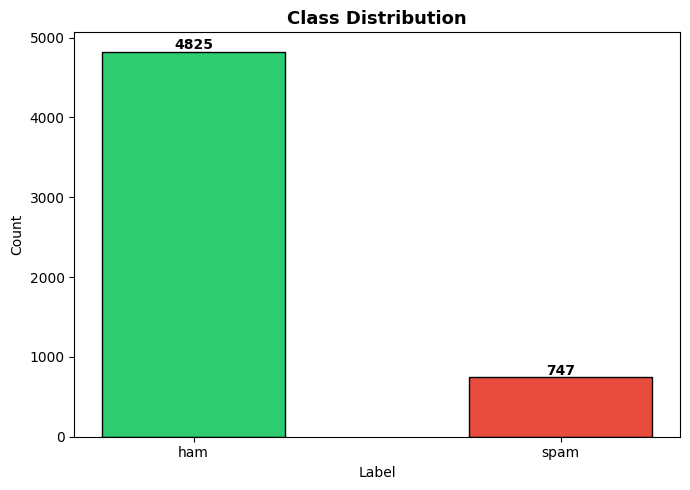

In [ ]:

#  Class Distribution Bar
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['label'].value_counts()
ax.bar(counts.index, counts.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()

plt.show()


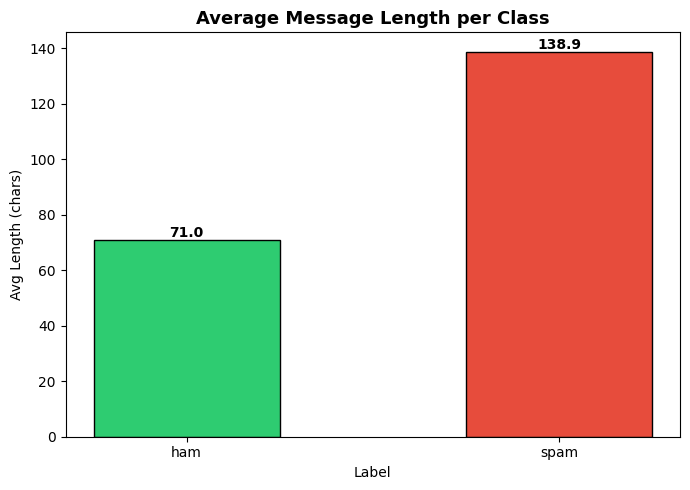

In [ ]:
#  Average Message Length
avg_len = df.groupby('label')['msg_length'].mean()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(avg_len.index, avg_len.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
ax.set_title('Average Message Length per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Avg Length (chars)')
for i, v in enumerate(avg_len.values):
    ax.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()

plt.show()


In [ ]:
#  Preprocessing

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess)


print("=== Preprocessing Example ===")
print("Before:", df['message'][2])
print("After :", df['clean_message'][2])

=== Preprocessing Example ===
Before: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
After : free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over


In [ ]:
#  TF-IDF + Train/Test Split + SMOTE

X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()
print(f"TF-IDF shape: {X_train_tfidf.shape}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)
print("After SMOTE:", dict(zip(*np.unique(y_train_bal, return_counts=True))))

TF-IDF shape: (4457, 1500)
After SMOTE: {np.int64(0): np.int64(3859), np.int64(1): np.int64(3859)}


In [ ]:
# SMOTE Before vs After

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution Before vs After SMOTE', fontsize=13, fontweight='bold')

before = dict(zip(*np.unique(y_train, return_counts=True)))
after  = dict(zip(*np.unique(y_train_bal, return_counts=True)))

axes[0].bar(['Ham', 'Spam'], [before[0], before[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([before[0], before[1]]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(['Ham', 'Spam'], [after[0], after[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate([after[0], after[1]]):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Fig3_smote.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Fig3_smote.png")

In [ ]:
#  Evaluate Function
# ============================================================
def evaluate(name, y_true, y_pred):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"  Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"  Recall   : {recall_score(y_true, y_pred)*100:.2f}%")
    print(f"  F1-Score : {f1_score(y_true, y_pred)*100:.2f}%")

def run_pso(fitness_fn, n_particles=40, n_iterations=60,
            w=0.5, c1=2.0, c2=2.0):
    N = X_train_tfidf.shape[1]

    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

    positions  = np.random.randint(0, 2, (n_particles, N))
    velocities = np.random.uniform(-1, 1, (n_particles, N))
    pbest      = positions.copy()
    pbest_fit  = np.array([fitness_fn(p) for p in pbest])
    gbest      = pbest[np.argmax(pbest_fit)].copy()
    gbest_fit  = np.max(pbest_fit)
    history    = []

    print("Running PSO...")
    for iteration in range(n_iterations):
        for i in range(n_particles):
            r1 = np.random.rand(N)
            r2 = np.random.rand(N)
            velocities[i] = (w  * velocities[i]
                           + c1 * r1 * (pbest[i] - positions[i])
                           + c2 * r2 * (gbest    - positions[i]))
            prob         = sigmoid(velocities[i])
            positions[i] = (np.random.rand(N) < prob).astype(int)
            fit = fitness_fn(positions[i])
            if fit > pbest_fit[i]:
                pbest[i]     = positions[i].copy()
                pbest_fit[i] = fit
                if fit > gbest_fit:
                    gbest     = positions[i].copy()
                    gbest_fit = fit
        history.append(gbest_fit)
        if (iteration + 1) % 10 == 0:
            print(f"  Iter {iteration+1:2d} | Fitness: {gbest_fit:.4f} | Features: {np.sum(gbest)}")

    n_sel = int(np.sum(gbest))
    red   = ((N - n_sel) / N) * 100
    print(f"PSO Done! Features: {n_sel} / {N} ({red:.1f}% reduction)")
    return gbest, history, n_sel, red

#  Naive Bayes — Baseline BEFORE PSO

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_bal, y_train_bal)
y_pred_nb = nb.predict(X_test_tfidf)
evaluate("Naive Bayes — BEFORE PSO", y_test, y_pred_nb)


  Naive Bayes — BEFORE PSO
  Accuracy : 96.05%
  Precision: 81.07%
  Recall   : 91.95%
  F1-Score : 86.16%


In [ ]:
#  PSO for Naive Bayes

def fitness_nb(particle):
    selected = np.where(particle == 1)[0]
    if len(selected) < 10:
        return 0
    X_tr = X_train_bal[:, selected]
    X_te = X_test_tfidf[:, selected]
    clf  = MultinomialNB()
    clf.fit(X_tr, y_train_bal)
    pred = clf.predict(X_te)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    return 0.7 * acc + 0.29 * f1 + 0.01 * (1 - len(selected)/X_train_tfidf.shape[1])

gbest_nb, history_nb, n_sel_nb, red_nb = run_pso(fitness_nb)

Running PSO...
  Iter 10 | Fitness: 0.9272 | Features: 762
  Iter 20 | Fitness: 0.9427 | Features: 723
  Iter 30 | Fitness: 0.9427 | Features: 723
  Iter 40 | Fitness: 0.9427 | Features: 723
  Iter 50 | Fitness: 0.9427 | Features: 723
  Iter 60 | Fitness: 0.9427 | Features: 723
PSO Done! Features: 723 / 1500 (51.8% reduction)


In [ ]:
#  Naive Bayes — AFTER PSO

sel_nb = np.where(gbest_nb == 1)[0]
nb_pso = MultinomialNB()
nb_pso.fit(X_train_bal[:, sel_nb], y_train_bal)
y_pred_nb_pso = nb_pso.predict(X_test_tfidf[:, sel_nb])
evaluate("Naive Bayes — AFTER PSO", y_test, y_pred_nb_pso)


  Naive Bayes — AFTER PSO
  Accuracy : 97.04%
  Precision: 88.16%
  Recall   : 89.93%
  F1-Score : 89.04%


In [ ]:
# Logistic Regression — Baseline BEFORE PSO

lr = LogisticRegression(max_iter=1000, random_state=42, C=5)
lr.fit(X_train_bal, y_train_bal)
y_pred_lr = lr.predict(X_test_tfidf)
evaluate("Logistic Regression — BEFORE PSO", y_test, y_pred_lr)


  Logistic Regression — BEFORE PSO
  Accuracy : 96.95%
  Precision: 86.62%
  Recall   : 91.28%
  F1-Score : 88.89%


In [ ]:
#  PSO for Logistic Regression
def fitness_lr(particle):
    selected = np.where(particle == 1)[0]
    if len(selected) < 10:
        return 0
    X_tr = X_train_bal[:, selected]
    X_te = X_test_tfidf[:, selected]
    clf  = LogisticRegression(max_iter=500, random_state=42, C=5)
    clf.fit(X_tr, y_train_bal)
    pred = clf.predict(X_te)
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    return 0.7 * acc + 0.29 * f1 + 0.01 * (1 - len(selected)/X_train_tfidf.shape[1])

gbest_lr, history_lr, n_sel_lr, red_lr = run_pso(fitness_lr)

Running PSO...
  Iter 10 | Fitness: 0.9457 | Features: 745
  Iter 20 | Fitness: 0.9481 | Features: 755
  Iter 30 | Fitness: 0.9481 | Features: 755
  Iter 40 | Fitness: 0.9505 | Features: 762
  Iter 50 | Fitness: 0.9505 | Features: 762
  Iter 60 | Fitness: 0.9505 | Features: 762
PSO Done! Features: 762 / 1500 (49.2% reduction)


In [ ]:
# Logistic Regression — AFTER PSO
sel_lr = np.where(gbest_lr == 1)[0]
lr_pso = LogisticRegression(max_iter=1000, random_state=42, C=5)
lr_pso.fit(X_train_bal[:, sel_lr], y_train_bal)
y_pred_lr_pso = lr_pso.predict(X_test_tfidf[:, sel_lr])
evaluate("Logistic Regression — AFTER PSO", y_test, y_pred_lr_pso)


  Logistic Regression — AFTER PSO
  Accuracy : 97.49%
  Precision: 89.54%
  Recall   : 91.95%
  F1-Score : 90.73%


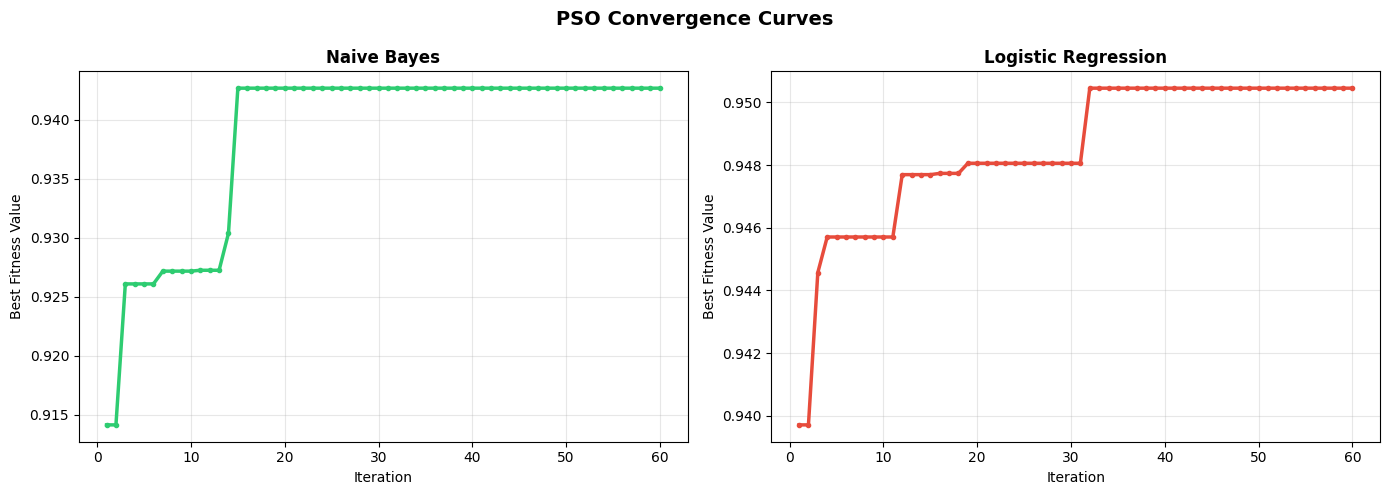

Saved: Fig_pso_convergence_both.png


In [ ]:
# PSO Convergence Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSO Convergence Curves', fontsize=14, fontweight='bold')

# NB
axes[0].plot(range(1, 61), history_nb, color='#2ecc71',
             linewidth=2.5, marker='o', markersize=3)
axes[0].set_title('Naive Bayes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Best Fitness Value')
axes[0].grid(True, alpha=0.3)

# LR
axes[1].plot(range(1, 61), history_lr, color='#e74c3c',
             linewidth=2.5, marker='o', markersize=3)
axes[1].set_title('Logistic Regression', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Best Fitness Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


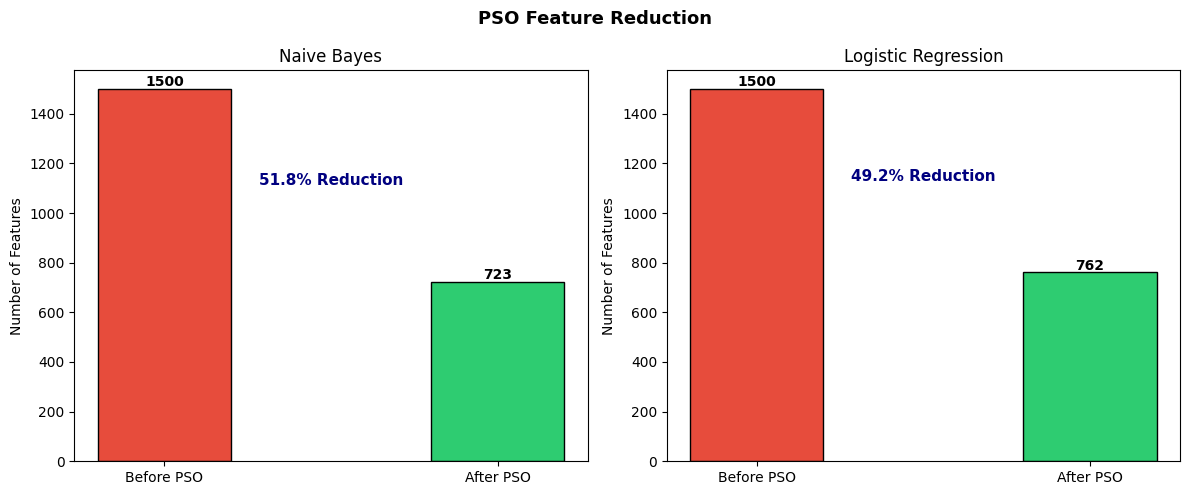

In [ ]:
#  Feature Reduction Comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PSO Feature Reduction', fontsize=13, fontweight='bold')

N = X_train_tfidf.shape[1]

axes[0].bar(['Before PSO', 'After PSO'], [N, n_sel_nb],
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
axes[0].set_title('Naive Bayes')
axes[0].set_ylabel('Number of Features')
for i, v in enumerate([N, n_sel_nb]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].annotate(f'{red_nb:.1f}% Reduction', xy=(0.5, (N+n_sel_nb)/2),
                 ha='center', fontsize=11, color='navy', fontweight='bold')

axes[1].bar(['Before PSO', 'After PSO'], [N, n_sel_lr],
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.4)
axes[1].set_title('Logistic Regression')
axes[1].set_ylabel('Number of Features')
for i, v in enumerate([N, n_sel_lr]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].annotate(f'{red_lr:.1f}% Reduction', xy=(0.5, (N+n_sel_lr)/2),
                 ha='center', fontsize=11, color='navy', fontweight='bold')

plt.tight_layout()

plt.show()


In [ ]:
# Final Results Table

df_results = pd.DataFrame({
    'Model'        : ['NB Before PSO', 'NB After PSO',
                      'LR Before PSO', 'LR After PSO'],
    'Features'     : [N, n_sel_nb, N, n_sel_lr],
    'Accuracy (%)'  : [accuracy_score(y_test, y_pred_nb)*100,
                       accuracy_score(y_test, y_pred_nb_pso)*100,
                       accuracy_score(y_test, y_pred_lr)*100,
                       accuracy_score(y_test, y_pred_lr_pso)*100],
    'Precision (%)' : [precision_score(y_test, y_pred_nb)*100,
                       precision_score(y_test, y_pred_nb_pso)*100,
                       precision_score(y_test, y_pred_lr)*100,
                       precision_score(y_test, y_pred_lr_pso)*100],
    'Recall (%)'   : [recall_score(y_test, y_pred_nb)*100,
                      recall_score(y_test, y_pred_nb_pso)*100,
                      recall_score(y_test, y_pred_lr)*100,
                      recall_score(y_test, y_pred_lr_pso)*100],
    'F1-Score (%)'  : [f1_score(y_test, y_pred_nb)*100,
                       f1_score(y_test, y_pred_nb_pso)*100,
                       f1_score(y_test, y_pred_lr)*100,
                       f1_score(y_test, y_pred_lr_pso)*100],
}).round(2)


print("FINAL RESULTS TABLE")
print("="*70)
print(df_results.to_string(index=False))
print(f"\nNB  Feature Reduction: {N} to {n_sel_nb} ({red_nb:.1f}%)")
print(f"LR  Feature Reduction: {N} to {n_sel_lr} ({red_lr:.1f}%)")

FINAL RESULTS TABLE
        Model  Features  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
NB Before PSO      1500         96.05          81.07       91.95         86.16
 NB After PSO       723         97.04          88.16       89.93         89.04
LR Before PSO      1500         96.95          86.62       91.28         88.89
 LR After PSO       762         97.49          89.54       91.95         90.73

NB  Feature Reduction: 1500 to 723 (51.8%)
LR  Feature Reduction: 1500 to 762 (49.2%)


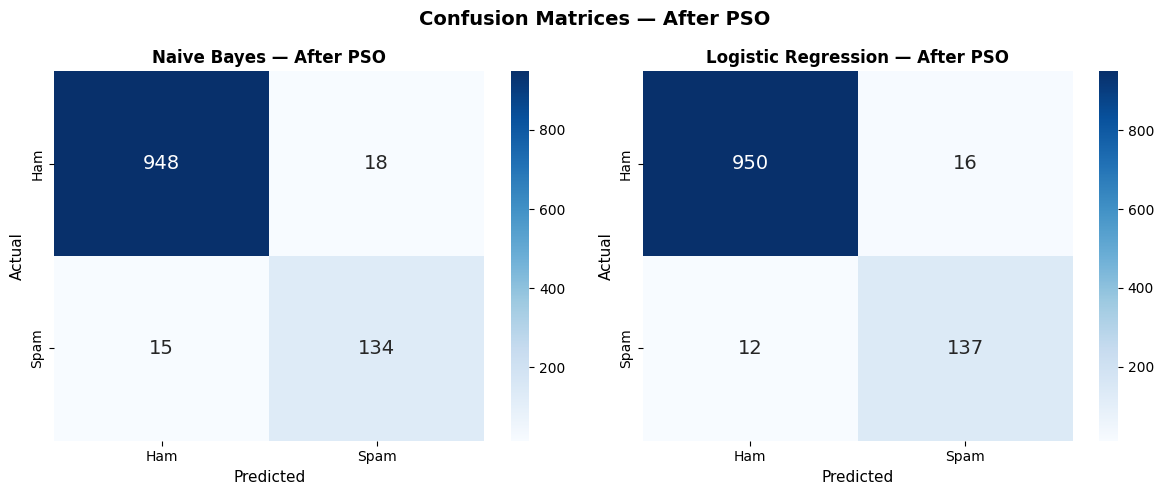

Saved: Fig_confusion_matrices.png


In [ ]:
# Confusion Matrices — After PSO
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — After PSO', fontsize=14, fontweight='bold')

cms = [("Naive Bayes — After PSO",       y_pred_nb_pso),
       ("Logistic Regression — After PSO", y_pred_lr_pso)]

for ax, (title, pred) in zip(axes, cms):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                ax=ax, annot_kws={"size": 14})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('Fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Fig_confusion_matrices.png")